
## In this python file we shall seek to thermodynamically model the charging of the CTES


We would like to find out, how much heat is stored in the concrete as a function of the flow + temperature of water through the tubes. The output will be the temperatures through all N blocks of the concrete.

In [ ]:
#Importing the constants

import sys
import os

# Add the project root to the path so we can import from src.data.constants
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.constants import (
    rho_con, Cp_con, lambda_con,
    D_int, D_ext,
    lambda_iso, th_iso, epsilon_iso,
    V_con, n_modules,
    module_width, module_height, module_length,
    A_LFC, n_LFC_modules, n_LFC_rows, A_LFC_module, A_soil_total
)

print("Constants imported successfully!")
print(f"  rho_con = {rho_con} kg/m³")
print(f"  Cp_con = {Cp_con} J/(kg·K)")
print(f"  lambda_con = {lambda_con} W/(m·K)")
print(f"  V_con = {V_con} m³")

Constants imported successfully!
  rho_con = 2340 kg/m³
  Cp_con = 920 J/(kg·K)
  lambda_con = 1.4 W/(m·K)
  V_con = 1319 m³


Considering a local cylindrical coordinate system with a longitudinal axis z going through the axis of symmetry of the whole storage element, the Neumann boundary-value problem for the heat equation
in the concrete volume is defined by:

![Neumann boundary-value problem](../../Pictures/P1_neuman_boundary-value_problem.png)

Where:

| Symbol | Description | Unit |
|--------|-------------|------|
| $\rho_{con}$ | Density of concrete | kg/m³ |
| $C_{p,con}$ | Specific heat capacity of concrete | J/(kg·K) |
| $T$ | Temperature in the concrete | K (or °C) |
| $t$ | Time | s |
| $r$ | Radial coordinate (distance from the axis of symmetry of the storage element) | m |
| $z$ | Longitudinal (axial) coordinate, coincident with the axis of symmetry | m |
| $\lambda_{con}$ | Thermal conductivity of concrete | W/(m·K) |
| $V_{eq}$ | Equivalent concrete volume of the representative storage element | m³ |
| $\dot{q}_{eq}$ | Heat flux at the external boundary of the equivalent element (accounts for thermal losses or interaction with adjacent elements) | W/m² |
| $S_{eq,ext}$ | External surface of the equivalent storage element | m² |
| $\dot{q}_{exch}$ | Heat flux exchanged between the heat-transfer fluid and the concrete at the internal boundary | W/m² |
| $S_{eq,int}$ | Internal surface of the equivalent storage element (i.e. the pipe–concrete interface) | m² |

For the first equation, we have:

The left-hand side, $\rho_{con} \cdot C_{p,con} \cdot \frac{\partial T}{\partial t}$, is the heat transfer per unit volume of concrete.

The right-hand side has **two terms** that describe *how* heat flows into or through the concrete:

1. **Radial conduction:** $\frac{1}{r}\frac{\partial}{\partial r}\!\left(\lambda_{con} \cdot r \cdot \frac{\partial T}{\partial r}\right)$

   This is heat spreading outward (or inward) from the pipe, perpendicular to its axis. The $\frac{1}{r}$ factor and the $r$ inside the derivative come from working in cylindrical coordinates — they account for the fact that as you move outward from the pipe, the "ring" of concrete at radius $r$ has a larger circumference, so the same radial heat flux is distributed over a bigger area. In practice, this is the dominant term: the hot fluid in the pipe heats the concrete radially outward.

2. **Axial conduction:** $\frac{\partial}{\partial z}\!\left(\lambda_{con} \cdot \frac{\partial T}{\partial z}\right)$

   This is heat flowing along the length of the pipe (the $z$-direction). If one section of concrete is hotter than its neighbours upstream or downstream, heat will conduct axially to even out the temperature. This term is typically smaller than the radial one, but matters when there are significant temperature gradients along the pipe length (e.g. the inlet end is much hotter than the outlet end during charging).

Together they say: *the rate at which a point in the concrete heats up equals the net heat conducted into that point from all directions (radial + axial).*

This equation is a partial differential equation, that, when solved, describes the temperature field T(r,z,t) at every point inside the concrete as a function of time.

The next two equations describe the heat flux densities \q__eq and \q__exch, which are simply the heat flux at the external surface of the storage element and the internal surface of the storage element, respectively. It says, that if we multiply the thermal conductivity with the change of temperature as we increase the radius from the center of the pipe, we get how much heat is transfered in that direction.

The negative sign comes from Fourier's law of heat conduction. As the temperature gradient is negative as r increases under charging (when the content of the pipe is hotter than the concrete), and we would like to indicate that the heat transfer then is positive (as we have the perspective of the CTES) then we need a negative sign in front of the term.

The CTES is a rectangular prism, but we model it as n identical cylinders of equal cross-sectional area centered on the pipe.

## Ditching the axial conduction term
To make the solution simpler, the axial conduction term is dropped from the heat conduction equation. The same simplification is done by TRNSYS type 604 in the paper. Furthermore, the term will have a markedly smaller effect magnitude-wise compared to the dial conduction term. Heat will still be distributed to all slices of the storage element, as the fluid flowing through the pipes makes sure of this.

## Solving the PDE

The PDE from Eq. 12 in the paper cannot be solved analytically for the real system.

Instead, we solve it numerically using the **method of lines**:
1. **Discretize space** (both radial $r$ and axial $z$) into a grid of nodes
2. **Replace spatial derivatives** with finite-difference approximations → turns the PDE into a large system of coupled ODEs in time
3. **Hand the ODE system** to `scipy.integrate.solve_ivp`, which handles adaptive time-stepping


### Radial finite-difference discretization (concrete)

We place $N_r$ nodes at positions $r_0, r_1, \ldots, r_{N_r-1}$ uniformly spaced from $r_a = D_{ext}/2$ (pipe outer wall) to $r_b = r_{eq}$ (equivalent outer radius). The spacing is $\Delta r = (r_b - r_a)/(N_r - 1)$.

The radial Laplacian in cylindrical coordinates is:

$$\frac{1}{r}\frac{\partial}{\partial r}\!\left(r\frac{\partial T}{\partial r}\right) = \frac{\partial^2 T}{\partial r^2} + \frac{1}{r}\frac{\partial T}{\partial r}$$

At interior node $i$ (where $1 \le i \le N_r - 2$), we use central differences:

$$\frac{\partial^2 T}{\partial r^2}\bigg|_i \approx \frac{T_{i+1} - 2T_i + T_{i-1}}{\Delta r^2}, \qquad \frac{\partial T}{\partial r}\bigg|_i \approx \frac{T_{i+1} - T_{i-1}}{2\Delta r}$$

So the discretized radial Laplacian is:

$$\frac{1}{r_i}\frac{\partial}{\partial r}\!\left(r\frac{\partial T}{\partial r}\right)\bigg|_i \approx \frac{T_{i+1} - 2T_i + T_{i-1}}{\Delta r^2} + \frac{1}{r_i}\frac{T_{i+1} - T_{i-1}}{2\Delta r}$$

And the ODE for each interior concrete node becomes:

$$\frac{dT_i}{dt} = \alpha \left[\frac{T_{i+1} - 2T_i + T_{i-1}}{\Delta r^2} + \frac{1}{r_i}\frac{T_{i+1} - T_{i-1}}{2\Delta r}\right]$$

where $\alpha = \lambda_{con}/(\rho_{con} C_{p,con})$ is the thermal diffusivity.

**Boundary conditions:**
- **Inner wall** ($i = 0$, $r = r_a$): The pipe wall temperature $T_{wall}$ is determined by convective heat transfer from the fluid (see coupling below). We use a **convective (Robin) boundary condition**: heat flux from fluid through pipe wall equals conductive flux into concrete.
- **Outer wall** ($i = N_r - 1$, $r = r_b$): Neumann condition from Eq. 13 of the paper:
$$-\lambda_{con}\frac{\partial T}{\partial r}\bigg|_{r=r_b} = h_{eq}(T_{N_r-1} - T_{air})$$
This accounts for thermal losses through the insulation to the environment.

### Fluid energy balance (axial)

The fluid flows through the pipe along $z$ and exchanges heat with the concrete at the pipe wall. We discretize the pipe into $N_z$ axial nodes at positions $z_0, z_1, \ldots, z_{N_z-1}$, spaced $\Delta z = L_{CTES}/(N_z - 1)$.

The energy balance for the fluid in a small axial segment is:

$$\rho_f C_{p,f} A_f \frac{\partial T_f}{\partial t} = -\dot{m} C_{p,f} \frac{\partial T_f}{\partial z} + \pi D_{int}\, h_f\, \bigl(T_{con,0}(z) - T_f(z)\bigr)$$

where:

| Symbol | Description | Unit |
|--------|-------------|------|
| $\rho_f$ | Density of the HTF | kg/m³ |
| $C_{p,f}$ | Specific heat capacity of the HTF | J/(kg·K) |
| $A_f = \pi D_{int}^2 / 4$ | Cross-sectional area of the pipe interior | m² |
| $\dot{m}$ | Mass flow rate of the HTF through one pipe | kg/s |
| $D_{int}$ | Inner pipe diameter | m |
| $h_f$ | Convective heat transfer coefficient (fluid → pipe wall) | W/(m²·K) |
| $T_{con,0}(z)$ | Concrete temperature at the innermost radial node ($r = r_a$) at this $z$ | °C |
| $T_f(z)$ | Fluid temperature at this axial position | °C |

**Term by term:**
1. **Left-hand side**: rate of thermal energy storage in the fluid volume at this $z$-slice (the fluid's own thermal inertia)
2. **$-\dot{m} C_{p,f} \frac{\partial T_f}{\partial z}$**: advection — the fluid carries enthalpy downstream. When $T_f$ decreases along $z$ (during charging), this term is positive, meaning the fluid is depositing heat. We discretize this with an **upwind scheme**: $\partial T_f/\partial z \approx (T_{f,j} - T_{f,j-1})/\Delta z$
3. **$\pi D_{int} h_f (T_{con,0} - T_f)$**: convective exchange per unit pipe length — heat from the pipe wall enters the fluid if $T_{con,0} > T_f$, or leaves (as during charging when $T_f > T_{con,0}$)

The boundary condition at $z = 0$ is the known inlet fluid temperature: $T_f(0, t) = T_{f,in}(t)$

### Coupling between fluid and concrete at the pipe wall

At the inner boundary ($r = r_a$), the heat leaving the fluid must equal the heat entering the concrete. Using a total thermal resistance $R_{tot}$ that includes convection from the fluid to the pipe inner wall plus conduction through the pipe wall:

$$R_{tot} = \frac{1}{h_f \pi D_{int} \Delta z} + \frac{\ln(D_{ext}/D_{int})}{2\pi \lambda_{pipe} \Delta z}$$

The heat flux into the concrete at node $(i=0, j)$ is:

$$\dot{Q}_{exch,j} = \frac{T_{f,j} - T_{con,0,j}}{R_{tot}}$$

This flux simultaneously:
- **Removes** heat from the fluid: appears as a sink in the fluid ODE
- **Adds** heat to the innermost concrete node: provides the inner boundary condition for the radial diffusion

For the concrete inner boundary, we use a **ghost node** approach: the flux at $r = r_a$ is matched to the discretized conduction, giving:

$$\frac{dT_{con,0,j}}{dt} = \alpha\left[\frac{2(T_{con,1,j} - T_{con,0,j})}{\Delta r^2} + \frac{1}{r_0}\frac{T_{con,1,j} - T_{con,0,j}}{\Delta r}\right] + \frac{\dot{Q}_{exch,j}}{\rho_{con} C_{p,con} V_{node,0}}$$

where $V_{node,0} = \pi(r_{0+\frac{1}{2}}^2 - r_a^2)\Delta z$ is the volume of the innermost concrete shell.

### Summary of the ODE system

At each axial slice $j$, we have $N_r$ concrete unknowns + 1 fluid unknown. With $N_z$ axial slices, the total system has:

$$N_{total} = N_z \times (N_r + 1) \text{ coupled ODEs}$$

For $N_r = 20, N_z = 30$, that's 630 ODEs — easily handled by `solve_ivp` with the `Radau` method (implicit, stiff-friendly).

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# 1.  Physical Parameters
# ============================================================

# Thermal diffusivity of concrete [m^2/s]
alpha_con = lambda_con / (rho_con * Cp_con)

# Pipe geometry
r_a = D_ext / 2          # inner radius of concrete annulus = pipe outer radius [m]
r_int = D_int / 2        # pipe inner radius [m]
L_CTES = module_length   # length of one CTES module [m]

# Pipe pitch (square pitch) — compute from CTES module cross-section
# Module cross-section (excluding insulation): (W - 2*th_iso) x (H - 2*th_iso)
W_con = module_width  - 2 * th_iso    # concrete width [m]
H_con = module_height - 2 * th_iso    # concrete height [m]
A_cross = W_con * H_con               # cross-sectional area of concrete [m^2]

# Number of pipes per module: from total concrete volume
V_module = V_con / n_modules                           # concrete volume per module [m^3]
A_cross_eff = V_module / L_CTES                        # effective cross-section area [m^2]
# Estimate pipe pitch assuming square arrangement
n_pipes_approx = A_cross_eff / (0.08**2)               # initial guess with 80mm pitch
pipe_pitch = np.sqrt(A_cross_eff / round(n_pipes_approx))  # refined pitch [m]
n_pipes = int(round(A_cross_eff / pipe_pitch**2))

# Equivalent outer radius: circle with same area as pitch^2
r_b = pipe_pitch / np.sqrt(np.pi)

# Fluid properties (Paratherm NF thermal oil at ~200 deg C, approximate)
rho_f  = 780.0        # density [kg/m^3]
Cp_f   = 2200.0       # specific heat [J/(kg·K)]
mu_f   = 0.5e-3       # dynamic viscosity [Pa·s]
k_f    = 0.12         # thermal conductivity [W/(m·K)]

# Pipe wall thermal conductivity (steel)
lambda_pipe = 50.0    # [W/(m·K)]

# Flow conditions
A_f = np.pi * r_int**2                       # pipe cross-sectional area [m^2]
m_dot_total = 0.5                             # total mass flow rate through one module [kg/s]
m_dot = m_dot_total / n_pipes                 # mass flow per pipe [kg/s]
v_f = m_dot / (rho_f * A_f)                   # fluid velocity [m/s]

# Convective heat transfer coefficient (Dittus-Boelter for turbulent flow)
Re = rho_f * v_f * D_int / mu_f
Pr = mu_f * Cp_f / k_f
if Re > 2300:
    Nu = 0.023 * Re**0.8 * Pr**0.4           # Dittus-Boelter (heating)
else:
    Nu = 3.66                                  # Laminar fully-developed
h_f = Nu * k_f / D_int                        # [W/(m^2·K)]

# Equivalent external heat transfer coefficient (Eq. 19 from paper)
# Simplified: combines insulation conduction + external convection/radiation
h_conv_ext = 5.0       # external convective+radiative [W/(m^2·K)] (low wind)
S_iso_ext = 2 * (module_width + module_height) * L_CTES  # external insulation surface [m^2]
S_con_ext = 2 * (W_con + H_con) * L_CTES                 # concrete external surface [m^2]
S_eq_ext  = np.pi * 2 * r_b * L_CTES                     # single element external surface [m^2]

# Thermal resistance: insulation + external convection (per unit area of concrete surface)
R_ext_inv = 1.0 / (1.0 / (h_conv_ext * S_iso_ext) + th_iso / (lambda_iso * S_con_ext))
h_eq = R_ext_inv / (n_pipes * S_eq_ext)       # equivalent h for one element [W/(m^2·K)]

# Initial and boundary conditions
T_0    = 25.0     # initial concrete + fluid temperature [deg C]
T_air  = 25.0     # ambient temperature [deg C]
T_f_in = 250.0    # inlet fluid temperature during charging [deg C]

# ============================================================
# 2.  Spatial Grid
# ============================================================

N_r = 20     # number of radial nodes in concrete
N_z = 30     # number of axial nodes along pipe

r_nodes = np.linspace(r_a, r_b, N_r)
z_nodes = np.linspace(0, L_CTES, N_z)
dr = r_nodes[1] - r_nodes[0]
dz = z_nodes[1] - z_nodes[0]

# Volume of each radial shell (per unit z-length) — for energy calculations
r_edges = np.zeros(N_r + 1)
r_edges[0]    = r_a
r_edges[N_r]  = r_b
r_edges[1:N_r] = 0.5 * (r_nodes[:-1] + r_nodes[1:])
V_shells = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2)  # [m^2] (per unit z)

# Thermal resistance: convection + pipe wall conduction (per unit pipe length)
R_conv = 1.0 / (h_f * np.pi * D_int)                        # convective [K·m/W]
R_cond_pipe = np.log(D_ext / D_int) / (2 * np.pi * lambda_pipe)  # pipe wall [K·m/W]
R_tot = R_conv + R_cond_pipe                                 # total per unit length [K·m/W]

# Print summary
print("=" * 60)
print("CTES Numerical Model — Grid & Parameter Summary")
print("=" * 60)
print(f"  Thermal diffusivity  alpha  = {alpha_con:.4e} m^2/s")
print(f"  Inner radius         r_a    = {r_a*1e3:.2f} mm")
print(f"  Outer radius         r_b    = {r_b*1e3:.2f} mm")
print(f"  Annulus thickness           = {(r_b - r_a)*1e3:.2f} mm")
print(f"  Pipe pitch                  = {pipe_pitch*1e3:.1f} mm")
print(f"  Number of pipes/module      = {n_pipes}")
print(f"  Pipe length          L      = {L_CTES:.1f} m")
print(f"  Δr = {dr*1e3:.3f} mm,   Δz = {dz:.3f} m")
print(f"  Reynolds number      Re     = {Re:.0f}")
print(f"  Nusselt number       Nu     = {Nu:.1f}")
print(f"  h_f (convection)            = {h_f:.1f} W/(m^2·K)")
print(f"  h_eq (external loss)        = {h_eq:.4f} W/(m^2·K)")
print(f"  R_tot (fluid→concrete)      = {R_tot:.4f} K·m/W")
print(f"  Fluid velocity              = {v_f:.3f} m/s")
print(f"  Total ODEs                  = {N_z * (N_r + 1)}")

CTES Numerical Model — Grid & Parameter Summary
  Thermal diffusivity  alpha  = 6.5032e-07 m^2/s
  Inner radius         r_a    = 12.50 mm
  Outer radius         r_b    = 45.13 mm
  Annulus thickness           = 32.63 mm
  Pipe pitch                  = 80.0 mm
  Number of pipes/module      = 818
  Pipe length          L      = 18.0 m
  Δr = 1.717 mm,   Δz = 0.621 m
  Reynolds number      Re     = 74
  Nusselt number       Nu     = 3.7
  h_f (convection)            = 20.9 W/(m^2·K)
  h_eq (external loss)        = 0.0080 W/(m^2·K)
  R_tot (fluid→concrete)      = 0.7253 K·m/W
  Fluid velocity              = 0.002 m/s
  Total ODEs                  = 630


In [5]:
# ============================================================
# 3.  Right-Hand Side Function  (the core of the solver)
# ============================================================
#
# State vector layout:  y = [ T_con(r_0,z_0), T_con(r_1,z_0), ..., T_con(r_{Nr-1},z_0),  T_f(z_0),
#                              T_con(r_0,z_1), ...,                                         T_f(z_1),
#                              ...
#                              T_con(r_0,z_{Nz-1}), ...,                                    T_f(z_{Nz-1}) ]
#
# For each axial slice j, there are (N_r + 1) unknowns:
#   indices  j*(N_r+1)  to  j*(N_r+1) + N_r - 1   → concrete radial nodes
#   index    j*(N_r+1) + N_r                        → fluid temperature
#
# Total size: N_z * (N_r + 1)

stride = N_r + 1   # unknowns per axial slice

def rhs(t, y):
    """
    Compute dy/dt for the coupled concrete + fluid ODE system.
    """
    dydt = np.zeros_like(y)
    
    for j in range(N_z):
        # --- Extract state for this axial slice ---
        base = j * stride
        T_c = y[base : base + N_r]     # concrete temperatures at this z-slice
        T_fl = y[base + N_r]           # fluid temperature at this z-slice
        
        # ─── Heat exchange: fluid ↔ concrete inner wall ───
        # Q_exch per unit pipe length [W/m]:  (T_fluid - T_concrete_inner) / R_tot
        Q_exch_per_m = (T_fl - T_c[0]) / R_tot   # positive when fluid heats concrete
        
        # ─── Concrete radial diffusion (interior nodes i = 1 ... N_r-2) ───
        dTc = np.zeros(N_r)
        for i in range(1, N_r - 1):
            d2T_dr2 = (T_c[i+1] - 2*T_c[i] + T_c[i-1]) / dr**2
            dT_dr   = (T_c[i+1] - T_c[i-1]) / (2*dr)
            dTc[i]  = alpha_con * (d2T_dr2 + dT_dr / r_nodes[i])
        
        # ─── Inner boundary (i = 0): convective flux from fluid ───
        # Heat flux into the first concrete shell = Q_exch_per_m * dz
        # Spread over the shell volume: V_shells[0] * dz * rho_con * Cp_con
        # Plus conduction from node 1:
        d2T_inner = 2 * (T_c[1] - T_c[0]) / dr**2     # one-sided 2nd derivative
        dT_inner  = (T_c[1] - T_c[0]) / dr             # one-sided 1st derivative
        dTc[0] = alpha_con * (d2T_inner + dT_inner / r_nodes[0]) \
                 + Q_exch_per_m / (rho_con * Cp_con * V_shells[0])
        
        # ─── Outer boundary (i = N_r-1): heat loss to environment ───
        # -lambda_con * dT/dr |_{r_b} = h_eq * (T_{N_r-1} - T_air)
        # Use ghost node: T_{N_r} = T_{N_r-2} - 2*dr*h_eq*(T_{N_r-1} - T_air)/lambda_con
        T_ghost = T_c[N_r-2] - 2*dr * h_eq * (T_c[N_r-1] - T_air) / lambda_con
        d2T_outer = (T_ghost - 2*T_c[N_r-1] + T_c[N_r-2]) / dr**2
        dT_outer  = (T_ghost - T_c[N_r-2]) / (2*dr)
        dTc[N_r-1] = alpha_con * (d2T_outer + dT_outer / r_nodes[N_r-1])
        
        dydt[base : base + N_r] = dTc
        
        # ─── Fluid energy balance ───
        # dT_f/dt = -(m_dot*Cp_f/rho_f/Cp_f/A_f) * dT_f/dz  
        #           + pi*D_int*h_f*(T_c[0] - T_f) / (rho_f*Cp_f*A_f)
        # The exchange term has opposite sign from concrete (fluid loses heat)
        
        if j == 0:
            # Inlet: T_f is fixed at T_f_in (handled below), but we still need 
            # the advection for downstream nodes. Set dT_f/dt = 0 for inlet.
            dydt[base + N_r] = 0.0
        else:
            # Upwind advection:  dT_f/dz ≈ (T_f[j] - T_f[j-1]) / dz
            T_fl_prev = y[(j-1)*stride + N_r]
            advection = -m_dot * Cp_f * (T_fl - T_fl_prev) / dz
            
            # Convective exchange with concrete (per unit length * dz = per segment)
            exchange = -Q_exch_per_m   # fluid loses what concrete gains
            
            # Total:  rho_f * Cp_f * A_f * dz * dT_f/dt = advection*dz + exchange*dz
            # (the dz cancels from both sides when we write per-unit-length)
            dydt[base + N_r] = (advection + exchange) / (rho_f * Cp_f * A_f)
    
    # Force inlet fluid temperature to remain at T_f_in
    dydt[N_r] = 0.0
    
    return dydt


print("RHS function defined.")
print(f"State vector size: {N_z * stride} ({N_z} axial slices x {stride} unknowns each)")

RHS function defined.
State vector size: 630 (30 axial slices x 21 unknowns each)


In [6]:
# ============================================================
# 4.  Initial Condition & Solve
# ============================================================

# Initial state: everything at T_0, except inlet fluid at T_f_in
y0 = np.full(N_z * stride, T_0)
for j in range(N_z):
    y0[j * stride + N_r] = T_0       # fluid starts at T_0 everywhere
y0[N_r] = T_f_in                      # except inlet node = T_f_in

# Simulation time: 4 hours of charging
t_end = 4 * 3600   # [s]
t_eval = np.linspace(0, t_end, 200)   # output times

print("Solving ODE system with solve_ivp (Radau method)...")
print(f"  Time span: 0 to {t_end/3600:.0f} hours")
print(f"  Number of ODEs: {len(y0)}")
print(f"  Output snapshots: {len(t_eval)}")

sol = solve_ivp(
    rhs, 
    [0, t_end], 
    y0,
    method='Radau',         # implicit method, good for stiff diffusion problems
    t_eval=t_eval,
    rtol=1e-6,
    atol=1e-8,
    max_step=60.0           # max 60s steps to capture dynamics
)

print(f"\n  Status: {'Success' if sol.success else 'FAILED — ' + sol.message}")
print(f"  Time steps used: {len(sol.t)}")
print(f"  RHS evaluations: {sol.nfev}")

# ============================================================
# 5.  Extract Results
# ============================================================

def get_T_concrete(sol, t_idx, j_axial):
    """Get radial concrete profile at time index t_idx and axial slice j."""
    base = j_axial * stride
    return sol.y[base:base + N_r, t_idx]

def get_T_fluid(sol, t_idx):
    """Get fluid temperature along z at time index t_idx."""
    return np.array([sol.y[j * stride + N_r, t_idx] for j in range(N_z)])

def get_T_field(sol, t_idx):
    """Get full 2D temperature field T(r, z) at time index t_idx."""
    T = np.zeros((N_r, N_z))
    for j in range(N_z):
        T[:, j] = get_T_concrete(sol, t_idx, j)
    return T

def get_stored_energy(sol, t_idx):
    """
    Total thermal energy stored in one module [J].
    E = n_pipes * sum_j sum_i rho * Cp * (T_ij - T_0) * V_shell_i * dz
    """
    E = 0.0
    for j in range(N_z):
        T_c = get_T_concrete(sol, t_idx, j)
        E += np.sum(rho_con * Cp_con * (T_c - T_0) * V_shells * dz)
    return E * n_pipes   # scale to full module

Solving ODE system with solve_ivp (Radau method)...
  Time span: 0 to 4 hours
  Number of ODEs: 630
  Output snapshots: 200

  Status: Success
  Time steps used: 200
  RHS evaluations: 1850


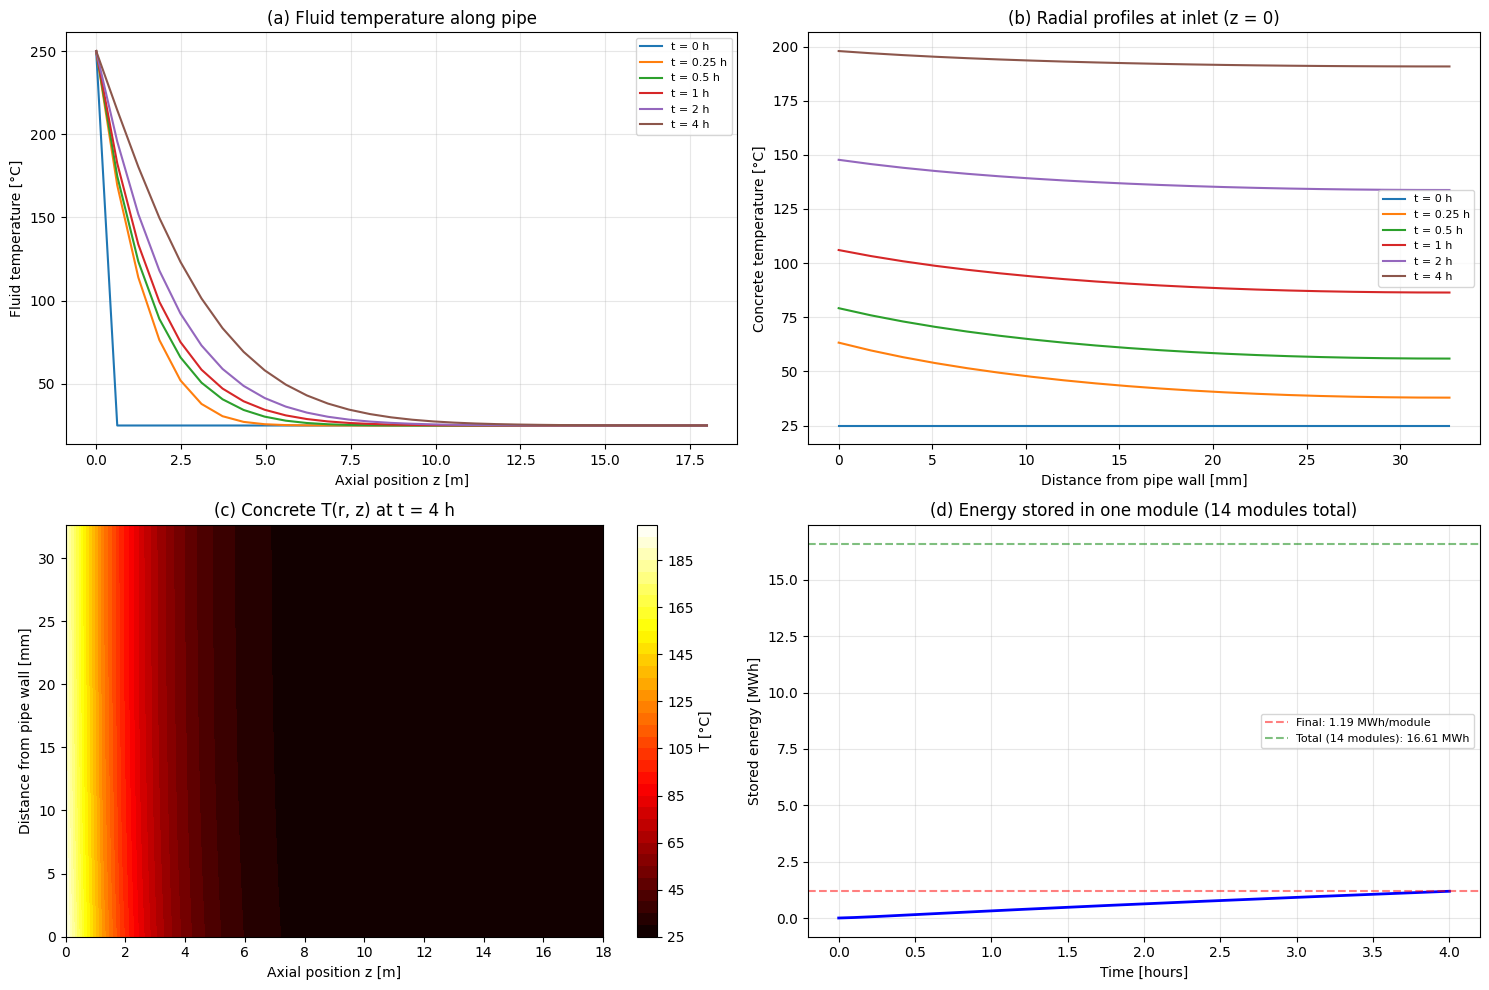

CHARGING SUMMARY
  Charging duration:    4 hours
  Inlet fluid temp:     250 °C
  Outlet fluid temp:    25.0 °C
  Avg concrete temp:    47.2 °C
  Energy per module:    1.19 MWh
  Total energy (14 mod): 16.61 MWh


In [7]:
# ============================================================
# 6.  Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- (a) Fluid temperature along z at several times ---
ax = axes[0, 0]
for t_h in [0, 0.25, 0.5, 1, 2, 4]:
    t_idx = np.argmin(np.abs(sol.t - t_h * 3600))
    T_fl = get_T_fluid(sol, t_idx)
    ax.plot(z_nodes, T_fl, label=f't = {t_h:.2g} h')
ax.set_xlabel('Axial position z [m]')
ax.set_ylabel('Fluid temperature [°C]')
ax.set_title('(a) Fluid temperature along pipe')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (b) Radial concrete profiles at inlet (z=0) at several times ---
ax = axes[0, 1]
dr_mm = (r_nodes - r_a) * 1e3
for t_h in [0, 0.25, 0.5, 1, 2, 4]:
    t_idx = np.argmin(np.abs(sol.t - t_h * 3600))
    T_c = get_T_concrete(sol, t_idx, j_axial=0)  # at inlet
    ax.plot(dr_mm, T_c, label=f't = {t_h:.2g} h')
ax.set_xlabel('Distance from pipe wall [mm]')
ax.set_ylabel('Concrete temperature [°C]')
ax.set_title(f'(b) Radial profiles at inlet (z = 0)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (c) 2D temperature field at t_end ---
ax = axes[1, 0]
T2d = get_T_field(sol, -1)
RR, ZZ = np.meshgrid(dr_mm, z_nodes, indexing='ij')
cf = ax.contourf(ZZ, RR, T2d, levels=40, cmap='hot')
fig.colorbar(cf, ax=ax, label='T [°C]')
ax.set_xlabel('Axial position z [m]')
ax.set_ylabel('Distance from pipe wall [mm]')
ax.set_title(f'(c) Concrete T(r, z) at t = {t_end/3600:.0f} h')

# --- (d) Stored energy vs time ---
ax = axes[1, 1]
E_stored = np.array([get_stored_energy(sol, i) for i in range(len(sol.t))])
E_MWh = E_stored / 3.6e9   # convert J to MWh
ax.plot(sol.t / 3600, E_MWh, 'b-', linewidth=2)
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Stored energy [MWh]')
ax.set_title(f'(d) Energy stored in one module ({n_modules} modules total)')
ax.axhline(y=E_MWh[-1], color='r', linestyle='--', alpha=0.5, 
           label=f'Final: {E_MWh[-1]:.2f} MWh/module')
ax.axhline(y=E_MWh[-1]*n_modules, color='g', linestyle='--', alpha=0.5,
           label=f'Total ({n_modules} modules): {E_MWh[-1]*n_modules:.2f} MWh')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("=" * 60)
print("CHARGING SUMMARY")
print("=" * 60)
print(f"  Charging duration:    {t_end/3600:.0f} hours")
print(f"  Inlet fluid temp:     {T_f_in:.0f} °C")
print(f"  Outlet fluid temp:    {get_T_fluid(sol, -1)[-1]:.1f} °C")
print(f"  Avg concrete temp:    {np.mean(get_T_field(sol, -1)):.1f} °C")
print(f"  Energy per module:    {E_MWh[-1]:.2f} MWh")
print(f"  Total energy ({n_modules} mod): {E_MWh[-1]*n_modules:.2f} MWh")